<a href="https://colab.research.google.com/github/jane-disciullo/sp500-backtesting-strategy/blob/main/04_out_of_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Out-of-Sample Validation

## Research Question

Does the 200-day moving-average strategy continue to perform when evaluated on data that was not used during parameter selection?

The strategy was previously evaluated across multiple moving-average windows using historical SPY data. Based on that analysis, the 200-day moving average was selected for further evaluation.

To reduce the risk of overfitting, the dataset is divided into two periods:

- **In-sample period:** 2015–2022
- **Out-of-sample period:** 2023–2025

The in-sample period is used for strategy development and parameter analysis, while the out-of-sample period is treated as unseen data. The 200-day moving-average strategy is evaluated against a buy-and-hold SPY benchmark using final portfolio value, total return, CAGR, Sharpe ratio, and maximum drawdown.

This notebook was developed with assistance from AI tools for debugging, troubleshooting, and syntax correction.

In [6]:
price = load_spy_data(
    start="2015-01-01",
    end="2026-01-01",
    interval="1d"
)

print(f"Data loaded: {price.shape[0]} rows")
print(f"Date range: {price.index.min()} to {price.index.max()}")

/content/sp500-backtesting-strategy/src/data.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price = yf.download(
[*********************100%***********************]  1 of 1 completed

Data loaded: 2766 rows
Date range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00


In [7]:
in_sample = price.loc["2015-01-01":"2022-12-31"].copy()
out_of_sample = price.loc["2023-01-01":"2025-12-31"].copy()

print("In-sample:")
print(f"Date range: {in_sample.index.min()} to {in_sample.index.max()}")
print(f"Rows: {len(in_sample)}")

print("\nOut-of-sample:")
print(f"Date range: {out_of_sample.index.min()} to {out_of_sample.index.max()}")
print(f"Rows: {len(out_of_sample)}")

In-sample:
Date range: 2015-01-02 00:00:00 to 2022-12-30 00:00:00
Rows: 2014

Out-of-sample:
Date range: 2023-01-03 00:00:00 to 2025-12-31 00:00:00
Rows: 752


In [8]:
strategy = price.copy()

strategy = generate_ma_signal(
    strategy,
    ma=200
)

strategy = run_backtest(
    strategy,
    starting_balance=100000
)

print(strategy.columns.tolist())

['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Return', 'Bench_Bal', 'MA', 'Long', 'Sys_Ret', 'Sys_Bal']


In [9]:
oos = strategy.loc["2023-01-01":"2025-12-31"].copy()

print(f"Out-of-sample rows: {len(oos)}")
print(f"Date range: {oos.index.min()} to {oos.index.max()}")

Out-of-sample rows: 752
Date range: 2023-01-03 00:00:00 to 2025-12-31 00:00:00


In [13]:
oos["OOS_Strategy_Bal"] = (
    100000 * oos["Sys_Ret"].cumprod()
)

oos["OOS_Bench_Bal"] = (
    100000 * oos["Return"].cumprod()
)

print(
    "Final OOS Strategy Balance:",
    f"${oos['OOS_Strategy_Bal'].iloc[-1]:,.2f}"
)

print(
    "Final OOS Benchmark Balance:",
    f"${oos['OOS_Bench_Bal'].iloc[-1]:,.2f}"
)

Final OOS Strategy Balance: $161,079.59
Final OOS Benchmark Balance: $185,497.58


## OOS Performance

The out-of-sample period begins 1-2023 and ends 12-2025. Both strategies are reset to a hypothetical $100,000 starting balance at the beginning of the test period.

The 200-day moving-average strategy was selected based on the earlier parameter analysis and was not re-optimized during the out-of-sample period. This provides a test of whether the strategy's historical behavior generalizes to previously unseen data.

In [19]:
def calculate_oos_metrics(data, balance_column, return_column):

    returns = (data[return_column] - 1).dropna()

    sharpe = (
        returns.mean() / returns.std()
    ) * np.sqrt(252)

    balance = data[balance_column].dropna()

    drawdown = balance / balance.cummax() - 1
    max_drawdown = drawdown.min()

    total_return = balance.iloc[-1] / 100000 - 1

    years = (
        balance.index[-1] - balance.index[0]
    ).days / 365.25

    cagr = (
        balance.iloc[-1] / 100000
    ) ** (1 / years) - 1

    return {
        "Final Balance": balance.iloc[-1],
        "Total Return": total_return,
        "CAGR": cagr,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

In [17]:
import numpy as np

In [21]:
oos_strategy_metrics = calculate_oos_metrics(
    oos,
    "OOS_Strategy_Bal",
    "Sys_Ret"
)

oos_benchmark_metrics = calculate_oos_metrics(
    oos,
    "OOS_Bench_Bal",
    "Return"
)

print("200-Day MA:")
print(oos_strategy_metrics)

print("\nBuy & Hold:")
print(oos_benchmark_metrics)

200-Day MA:
{'Final Balance': np.float64(161079.59148421793), 'Total Return': np.float64(0.6107959148421793), 'CAGR': np.float64(0.17270059430719042), 'Sharpe Ratio': np.float64(1.3955767451845271), 'Max Drawdown': -0.10018429456500422}

Buy & Hold:
{'Final Balance': np.float64(185497.5783201755), 'Total Return': np.float64(0.854975783201755), 'CAGR': np.float64(0.22933749744081755), 'Sharpe Ratio': np.float64(1.426203337212238), 'Max Drawdown': -0.18755226260622648}


In [23]:
import pandas as pd

In [24]:
oos_comparison = pd.DataFrame({
    "Strategy": ["Buy & Hold", "200-Day MA"],
    "Final Balance": [
        oos_benchmark_metrics["Final Balance"],
        oos_strategy_metrics["Final Balance"]
    ],
    "Total Return": [
        oos_benchmark_metrics["Total Return"],
        oos_strategy_metrics["Total Return"]
    ],
    "CAGR": [
        oos_benchmark_metrics["CAGR"],
        oos_strategy_metrics["CAGR"]
    ],
    "Sharpe Ratio": [
        oos_benchmark_metrics["Sharpe Ratio"],
        oos_strategy_metrics["Sharpe Ratio"]
    ],
    "Max Drawdown": [
        oos_benchmark_metrics["Max Drawdown"],
        oos_strategy_metrics["Max Drawdown"]
    ]
})

oos_comparison

,Strategy,Final Balance,Total Return,CAGR,Sharpe Ratio,Max Drawdown
0,Buy & Hold,185497.578320,0.854976,0.229337,1.426203,-0.187552
1,200-Day MA,161079.591484,0.610796,0.172701,1.395577,-0.100184


In [25]:
oos_comparison_display = oos_comparison.copy()

oos_comparison_display["Final Balance"] = (
    oos_comparison["Final Balance"]
    .map("${:,.2f}".format)
)

oos_comparison_display["Total Return"] = (
    oos_comparison["Total Return"] * 100
).round(2).astype(str) + "%"

oos_comparison_display["CAGR"] = (
    oos_comparison["CAGR"] * 100
).round(2).astype(str) + "%"

oos_comparison_display["Sharpe Ratio"] = (
    oos_comparison["Sharpe Ratio"]
    .round(2)
)

oos_comparison_display["Max Drawdown"] = (
    oos_comparison["Max Drawdown"] * 100
).round(2).astype(str) + "%"

oos_comparison_display

,Strategy,Final Balance,Total Return,CAGR,Sharpe Ratio,Max Drawdown
0,Buy & Hold,"$185,497.58",85.5%,22.93%,1.43,-18.76%
1,200-Day MA,"$161,079.59",61.08%,17.27%,1.40,-10.02%


## OOS Portfolio Growth

The chart below measures the growth of a (hypothetical) $100,000 investment in the 200-day MA strategy and buy-and-hold benchmark during the 2023–2025 OOS period.

Both portfolios are reset to $100,000 at the beginning of the test period.

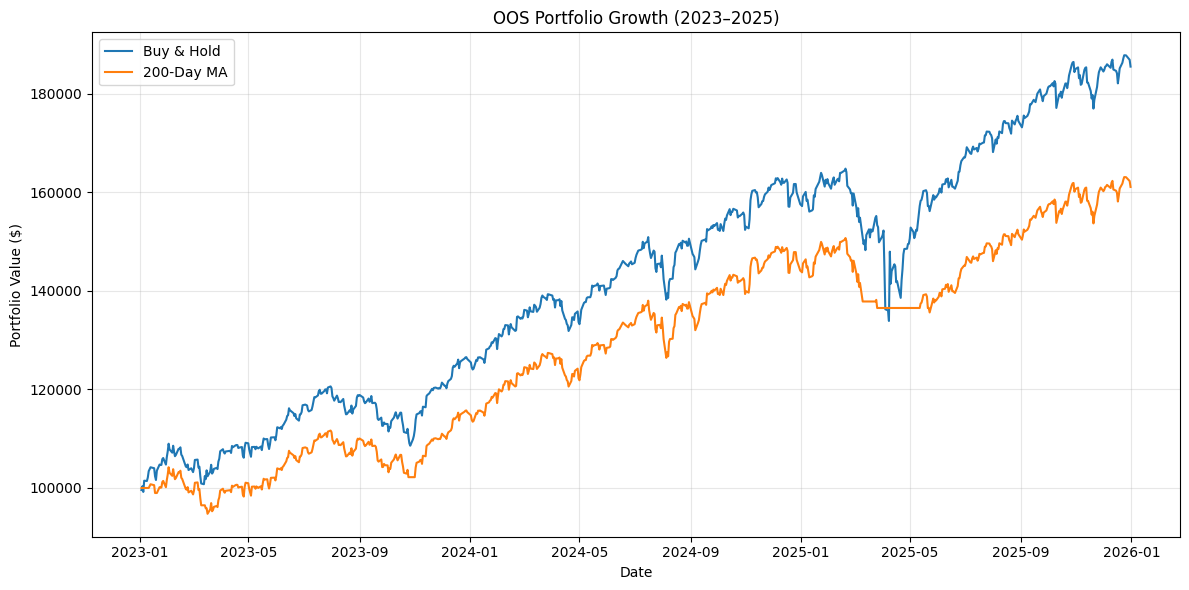

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    oos.index,
    oos["OOS_Bench_Bal"],
    label="Buy & Hold"
)

plt.plot(
    oos.index,
    oos["OOS_Strategy_Bal"],
    label="200-Day MA"
)

plt.title("OOS Portfolio Growth (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## OOS Drawdown Analysis

Drawdown measures the decline in portfolio value from a previous peak. Comparing drawdowns helps evaluate how effectively each strategy manages downside risk during the out-of-sample period.

The 200-day moving-average strategy produced a substantially smaller maximum drawdown than buy-and-hold, indicating lower downside exposure during 2023–2025.

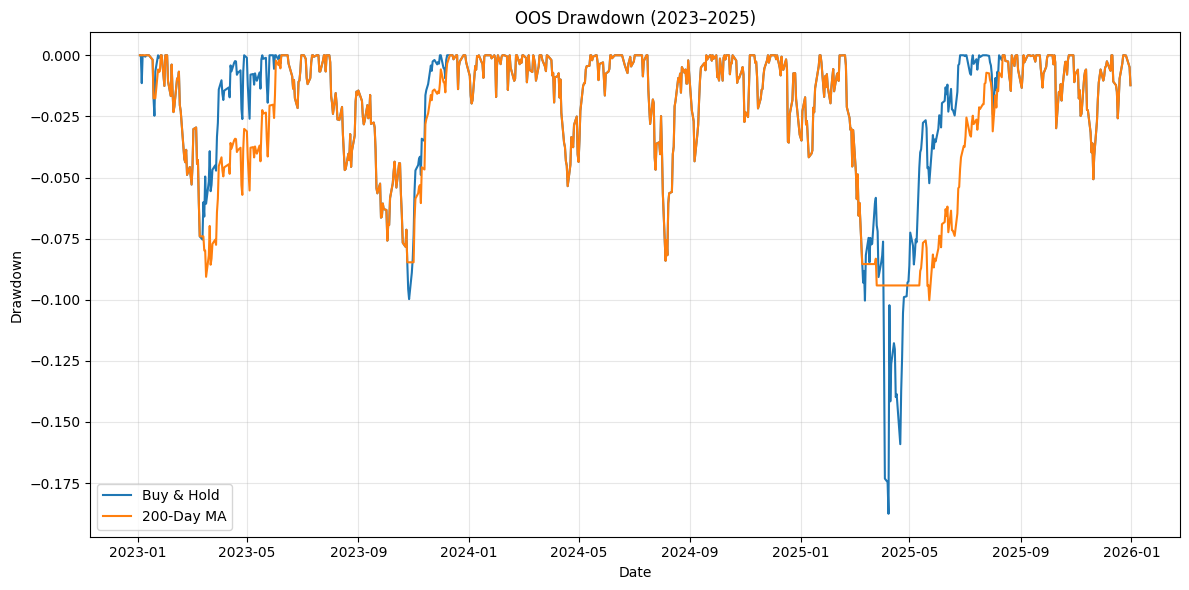

In [29]:
import matplotlib.pyplot as plt

strategy_drawdown = (
    oos["OOS_Strategy_Bal"] /
    oos["OOS_Strategy_Bal"].cummax()
) - 1

benchmark_drawdown = (
    oos["OOS_Bench_Bal"] /
    oos["OOS_Bench_Bal"].cummax()
) - 1

plt.figure(figsize=(12, 6))

plt.plot(
    oos.index,
    benchmark_drawdown,
    label="Buy & Hold"
)

plt.plot(
    oos.index,
    strategy_drawdown,
    label="200-Day MA"
)

plt.title("OOS Drawdown (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()